# Online Retails Purchase

### Introduction:



### Step 1. Import the necessary libraries

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Online_Retail/Online_Retail.csv). 

### Step 3. Assign it to a variable called online_rt
Note: if you receive a utf-8 decode error, set `encoding = 'latin1'` in `pd.read_csv()`.

In [3]:
url='https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Online_Retail/Online_Retail.csv'
online_rt=pd.read_csv(url, encoding = 'latin1', sep=',')

online_rt.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


### Step 4. Create a histogram with the 10 countries that have the most 'Quantity' ordered except UK

<Axes: xlabel='Country'>

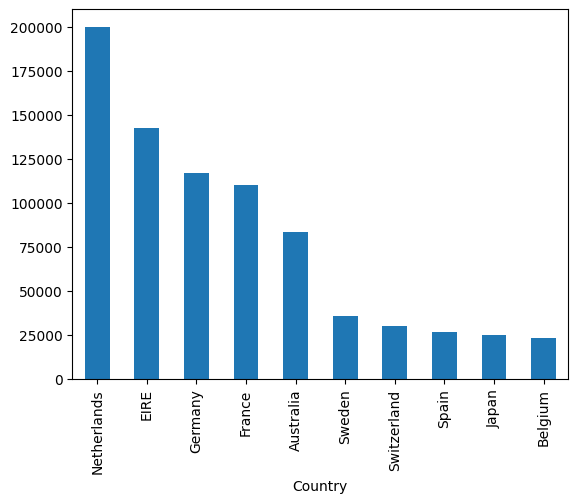

In [13]:
countries = online_rt.groupby('Country')
countries['Quantity'].sum().drop('United Kingdom').sort_values(ascending = False)[:10].plot(kind='bar')



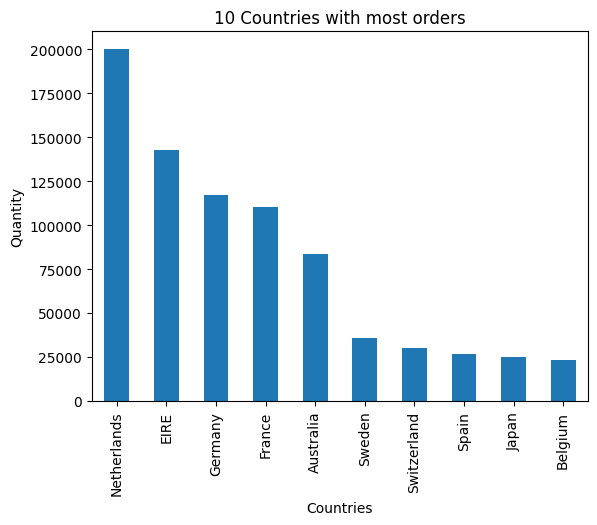

In [15]:
countries['Quantity'].sum().drop('United Kingdom').sort_values(ascending = False)[:10].plot(kind='bar')

# Set the title and labels
plt.xlabel('Countries')
plt.ylabel('Quantity')
plt.title('10 Countries with most orders')

# show the plot
plt.show()

### Step 5.  Exclude negative Quantity entries

In [16]:
online_rt = online_rt[online_rt.Quantity > 0]

### Step 6. Create a scatterplot with the Quantity per UnitPrice by CustomerID for the top 3 Countries (except UK)

In [ ]:
# CustomerID 就是每個客戶的唯一識別碼，你可以把它想成會員編號。同一個客戶可能出現在很多列，因為他可能買過很多次、每次買很多種商品。
# 所以這題在問的是：對於前三大國家的每一個客戶，他的「每單位金額換來的數量」是多少？
# Quantity / UnitPrice 這個比值有點像「CP值」的概念——同樣花一塊錢，你買到了幾個東西？這個數字大，代表這個客戶買的是低單價、大量的商品；數字小，代表他買的是高單價、少量的商品。

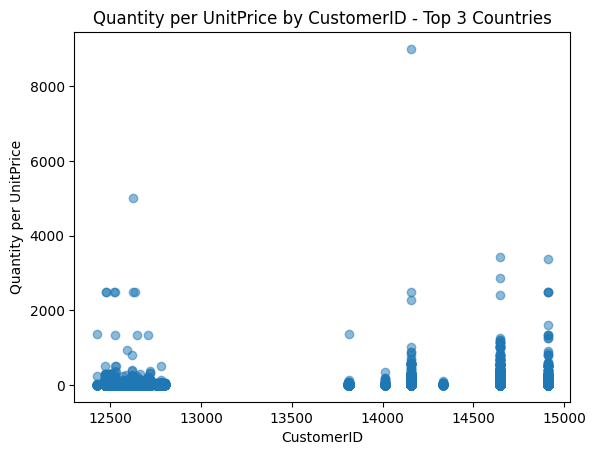

In [22]:
top3=['Netherlands','EIRE','Germany']
filtered = online_rt[online_rt['Country'].isin(top3)]

fig, ax = plt.subplots()


ax.scatter(filtered['CustomerID'], 
           filtered['Quantity'] / filtered['UnitPrice'],
           alpha=0.5)

ax.set_xlabel('CustomerID')
ax.set_ylabel('Quantity per UnitPrice')
ax.set_title('Quantity per UnitPrice by CustomerID - Top 3 Countries')


plt.show()

In [ ]:
# top3 分顏色

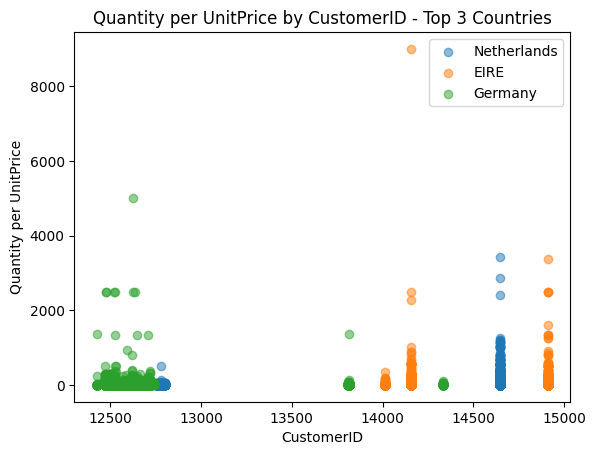

In [23]:
top3=['Netherlands','EIRE','Germany']
filtered = online_rt[online_rt['Country'].isin(top3)]

fig, ax = plt.subplots()

for country in top3:
    data = filtered[filtered['Country'] == country]
    ax.scatter(data['CustomerID'], 
               data['Quantity'] / data['UnitPrice'],
               label=country, alpha=0.5)

ax.set_xlabel('CustomerID')
ax.set_ylabel('Quantity per UnitPrice')
ax.set_title('Quantity per UnitPrice by CustomerID - Top 3 Countries')

ax.legend()
plt.show()

### Step 7. Investigate why the previous results look so uninformative.

This section might seem a bit tedious to go through. But I've thought of it as some kind of a simulation of problems one might encounter when dealing with data and other people. Besides there is a prize at the end (i.e. Section 8).

(But feel free to jump right ahead into Section 8 if you want; it doesn't require that you finish this section.)

#### Step 7.1 Look at the first line of code in Step 6. And try to figure out if it leads to any kind of problem.
##### Step 7.1.1 Display the first few rows of that DataFrame.

##### Step 7.1.2 Think about what that piece of code does and display the dtype of `UnitPrice`

In [31]:
online_rt['UnitPrice'].dtype

dtype('float64')

##### Step 7.1.3 Pull data from `online_rt`for `CustomerID`s 12346.0 and 12347.0.

In [30]:
online_rt[online_rt['CustomerID'] == 12347.0].sort_values(by='UnitPrice', ascending = False).head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
72267,542237,22423,REGENCY CAKESTAND 3 TIER,3,1/26/11 14:30,12.75,12347.0,Iceland
148300,549222,22423,REGENCY CAKESTAND 3 TIER,3,4/7/11 10:43,12.75,12347.0,Iceland
286637,562032,22423,REGENCY CAKESTAND 3 TIER,3,8/2/11 8:48,12.75,12347.0,Iceland
428966,573511,22423,REGENCY CAKESTAND 3 TIER,6,10/31/11 12:25,12.75,12347.0,Iceland
220577,556201,23173,REGENCY TEAPOT ROSES,2,6/9/11 13:01,9.95,12347.0,Iceland


#### Step 7.2 Reinterpreting the initial problem.

To reiterate the question that we were dealing with:  
"Create a scatterplot with the Quantity per UnitPrice by CustomerID for the top 3 Countries"

The question is open to a set of different interpretations.
We need to disambiguate.

We could do a single plot by looking at all the data from the top 3 countries.
Or we could do one plot per country. To keep things consistent with the rest of the exercise,
let's stick to the latter oprion. So that's settled.

But "top 3 countries" with respect to what? Two answers suggest themselves:
Total sales volume (i.e. total quantity sold) or total sales (i.e. revenue).
This exercise goes for sales volume, so let's stick to that.

##### Step 7.2.1 Find out the top 3 countries in terms of sales volume.

##### Step 7.2.2 

Now that we have the top 3 countries, we can focus on the rest of the problem:  
"Quantity per UnitPrice by CustomerID".  
We need to unpack that.

"by CustomerID" part is easy. That means we're going to be plotting one dot per CustomerID's on our plot. In other words, we're going to be grouping by CustomerID.

"Quantity per UnitPrice" is trickier. Here's what we know:  
*One axis will represent a Quantity assigned to a given customer. This is easy; we can just plot the total  Quantity for each customer.  
*The other axis will represent a UnitPrice assigned to a given customer. Remember a single customer can have any number of orders with different prices, so summing up prices isn't quite helpful. Besides it's not quite clear what we mean when we say "unit price per customer"; it sounds like price of the customer! A reasonable alternative is that we assign each customer the average amount each has paid per item. So let's settle that question in that manner.

#### Step 7.3 Modify, select and plot data
##### Step 7.3.1 Add a column to online_rt called `Revenue` calculate the revenue (Quantity * UnitPrice) from each sale.
We will use this later to figure out an average price per customer.

In [32]:
online_rt['Revenue']= online_rt['Quantity']*online_rt['UnitPrice']

##### Step 7.3.2 Group by `CustomerID` and `Country` and find out the average price (`AvgPrice`) each customer spends per unit.

In [36]:
AvgPrice=online_rt.groupby(['CustomerID','Country'])['Revenue'].mean().reset_index()
AvgPrice

,CustomerID,Country,Revenue
0,12346.0,United Kingdom,77183.600000
1,12347.0,Iceland,23.681319
2,12348.0,Finland,57.975484
3,12349.0,Italy,24.076027
4,12350.0,Norway,19.670588
...,...,...,...
4342,18280.0,United Kingdom,18.060000
4343,18281.0,United Kingdom,11.545714
4344,18282.0,United Kingdom,14.837500
4345,18283.0,United Kingdom,2.771005


##### Step 7.3.3 Plot

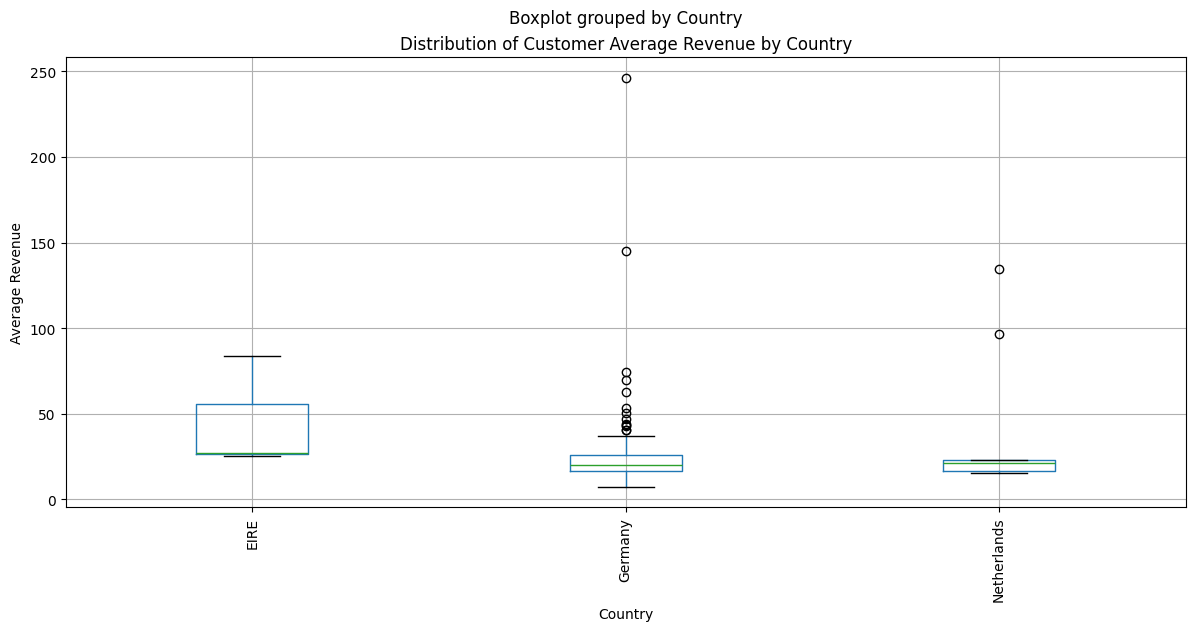

In [49]:
fig, ax = plt.subplots(figsize=(14, 6))

# 對每個國家的客戶平均Revenue畫boxplot

AvgPrice[AvgPrice['Country'].isin(top3)].boxplot(column='Revenue', by='Country', ax=ax)

ax.set_xlabel('Country')
ax.set_ylabel('Average Revenue')
ax.set_title('Distribution of Customer Average Revenue by Country')
plt.xticks(rotation=90)   #國家名稱旋轉90度，避免重疊
plt.show()

#### Step 7.4 What to do now?
We aren't much better-off than what we started with. The data are still extremely scattered around and don't seem quite informative.

But we shouldn't despair!
There are two things to realize:
1) The data seem to be skewed towaards the axes (e.g. we don't have any values where Quantity = 50000 and AvgPrice = 5). So that might suggest a trend.
2) We have more data! We've only been looking at the data from 3 different countries and they are plotted on different graphs.

So: we should plot the data regardless of `Country` and hopefully see a less scattered graph.

##### Step 7.4.1 Plot the data for each `CustomerID` on a single graph

##### Step 7.4.2 Zoom in so we can see that curve more clearly

### 8. Plot a line chart showing revenue (y) per UnitPrice (x).

Did Step 7 give us any insights about the data? Sure! As average price increases, the quantity ordered decreses.  But that's hardly surprising. It would be surprising if that wasn't the case!

Nevertheless the rate of drop in quantity is so drastic, it makes me wonder how our revenue changes with respect to item price. It would not be that surprising if it didn't change that much. But it would be interesting to know whether most of our revenue comes from expensive or inexpensive items, and how that relation looks like.

That is what we are going to do now.

#### 8.1 Group `UnitPrice` by intervals of 1 for prices [0,50), and sum `Quantity` and `Revenue`.

In [52]:
# 先建立區間，np.arange(0, 51, 1) 產生 [0,1,2,...,50] 作為切割點
bins = np.arange(0, 51, 1)

# 用 pd.cut() 把每個 UnitPrice 對應到它所屬的區間
online_rt['PriceBin'] = pd.cut(online_rt['UnitPrice'], bins=bins)

# 再用 groupby 對每個區間加總 Quantity 和 Revenue
result = online_rt.groupby('PriceBin')[['Quantity', 'Revenue']].sum()

#### 8.3 Plot.

<Axes: xlabel='PriceBin'>

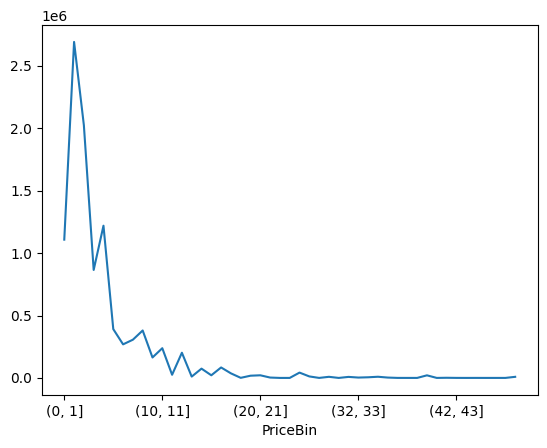

In [54]:
result['Revenue'].plot()

#### 8.4 Make it look nicer.
x-axis needs values.  
y-axis isn't that easy to read; show in terms of millions.

### BONUS: Create your own question and answer it.